# Exploratory Data Analysis (EDA)

In [56]:
#| output: false

import sys
from pathlib import Path
# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\CS273P_MachineLearning_Final_Project


In [57]:
from src.eda import effect_size
from src.eda import evaluate_kmeans_k, plot_k_diagnostics, choose_k_gap_rule, fit_kmeans, pca_project, plot_clusters_pca

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

from statsmodels.stats.outliers_influence import variance_inflation_factor


# Set plt plotting configs
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

In [58]:
#| output: false

# Data directories
DATA_DIR = Path("../data/raw")
SVI_PATH = DATA_DIR / "SVI_2022_US_county.csv"
SHAPE_PATH = DATA_DIR / "tl_2022_us_county/tl_2022_us_county.shp"

# Load svi.csv
svi = pd.read_csv(SVI_PATH)

# Load county lines
counties = gpd.read_file(SHAPE_PATH)

In [59]:
#| output: false

print(svi.shape)
svi.head()

(3144, 158)


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga County,1001,"Autauga County, Alabama",594.454786,58761,0,...,1.1,0.4,0.1,0.1,0.0,0.1,3.3,1.0,0.2,0.3
1,1,Alabama,AL,1003,Baldwin County,1003,"Baldwin County, Alabama",1589.861817,233420,0,...,0.9,0.1,0.2,0.1,0.0,0.1,3.1,0.4,0.4,0.3
2,1,Alabama,AL,1005,Barbour County,1005,"Barbour County, Alabama",885.007619,24877,0,...,0.5,0.1,0.3,0.1,0.0,0.1,1.8,0.7,1.2,0.8
3,1,Alabama,AL,1007,Bibb County,1007,"Bibb County, Alabama",622.469286,22251,0,...,0.3,0.4,0.1,0.1,0.0,0.2,1.7,1.0,0.1,0.1
4,1,Alabama,AL,1009,Blount County,1009,"Blount County, Alabama",644.890376,59077,0,...,0.2,0.2,0.1,0.1,0.2,0.2,2.8,0.7,0.1,0.1


In [60]:
#| output: false

print(counties.shape)
counties.head()

(3235, 18)


,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,None,None,None,A,1477644346,10691216,+41.9158651,-096.7885168,"POLYGON ((-96.55516 41.91587, -96.55515 41.914..."
1,53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680980770,61564427,+46.2946377,-123.4244583,"POLYGON ((-123.72755 46.2645, -123.72756 46.26..."
2,35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,None,None,None,A,6016818946,29090018,+34.3592729,-104.3686961,"POLYGON ((-104.89337 34.08894, -104.89337 34.0..."
3,31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,None,None,None,A,2169272978,22847034,+40.7835474,-096.6886584,"POLYGON ((-96.68493 40.5233, -96.69219 40.5231..."
4,31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,None,None,None,A,1489645185,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.2737 40.1184, -98.27374 40.1224,..."


## Data Preparation & Validation

In [62]:
# Standardize FIPS in svi
svi["FIPS"] = svi["FIPS"].astype(str).str.zfill(5)

# Extract FIPS as ID and required geometry
counties["FIPS"] = (counties["STATEFP"].astype(str) + counties["COUNTYFP"].astype(str)).str.zfill(5)
counties_c = counties[["FIPS", "geometry"]]

# Merge on FIPS
geo_df = svi.merge(
    counties_c[["FIPS", "geometry"]],
    on="FIPS",
    how="inner"
).sort_values("FIPS").reset_index(drop=True)

# Convert back to gpd
geo_df = gpd.GeoDataFrame(geo_df, geometry="geometry")

In [63]:
# Define SVI theme targets
target_cols = [
    "RPL_THEME1",
    "RPL_THEME2",
    "RPL_THEME3",
    "RPL_THEME4",
]

# Define overall target
overall_target = ["RPL_THEMES"]

# Define percentage indicators (EP_*)
feature_cols_ep = [
    "EP_POV150",
    "EP_UNEMP",
    "EP_NOHSDP",
    "EP_UNINSUR",
    "EP_AGE65",
    "EP_AGE17",
    "EP_DISABL",
    "EP_SNGPNT",
    "EP_LIMENG",
    "EP_MINRTY",
    "EP_MUNIT",
    "EP_MOBILE",
    "EP_CROWD",
    "EP_NOVEH",
    "EP_GROUPQ"
]

# Define raw count feature variables (E_*)
count_cols = [c for c in svi.columns if c.startswith("E_")]

# Define IDs
id_cols = [
    "FIPS",
    "STATE",
    "ST_ABBR",
    "COUNTY",
    "LOCATION"
]

# Define derived ranking variables (EPL_*, SPL_*, RPL_* ) to avoid leakage
derived_cols = [
    "EPL_POV150","EPL_UNEMP","EPL_NOHSDP","EPL_UNINSUR",
    "EPL_AGE65","EPL_AGE17","EPL_DISABL","EPL_SNGPNT",
    "EPL_LIMENG","EPL_MINRTY",
    "EPL_MUNIT","EPL_MOBILE","EPL_CROWD","EPL_NOVEH","EPL_GROUPQ",
    "SPL_THEME1","SPL_THEME2","SPL_THEME3","SPL_THEME4",
    "RPL_THEME1","RPL_THEME2","RPL_THEME3","RPL_THEME4",
    "RPL_THEMES"
]

# Define feature matrix (X) using percentage indicators
X = svi[feature_cols_ep].copy()

# Define target matrix (y) using target themes
y = svi[target_cols].copy()

In [64]:
#| label: tbl-svi-data-summary
#| tbl-cap: "Summary of the modeling datasets used in this study. The feature matrix (X) contains 3,144 U.S. counties and 15 socioeconomic and demographic indicators derived from the CDC Social Vulnerability Index (SVI) dataset. The target matrix (y) contains the four SVI theme percentile rankings (RPL_THEME1–RPL_THEME4), enabling a multi-task prediction framework. The spatial geometry dataset (geo_df) provides county polygon boundaries used to construct the spatial adjacency graph for Graph Neural Network modeling. No missing values were observed in the feature or target matrices."

dataset_summary = pd.DataFrame({
    "dataset": ["X (features)", "y (targets)", "geo_df (geometry)"],
    
    "dimensions": [
        f"{X.shape[0]} x {X.shape[1]}",
        f"{y.shape[0]} x {y.shape[1]}",
        f"{geo_df.shape[0]} x {geo_df.shape[1]}"
    ],
    
    "dtype": [
        ", ".join(X.dtypes.unique().astype(str)),
        ", ".join(y.dtypes.unique().astype(str)),
        ", ".join(geo_df.dtypes.unique().astype(str))
    ],
    
    "missing_values": [
        X.isna().sum().sum(),
        y.isna().sum().sum(),
        geo_df.isna().sum().sum()
    ],
    
    "missing_rate": [
        X.isna().sum().sum() / X.size,
        y.isna().sum().sum() / y.size,
        geo_df.isna().sum().sum() / geo_df.size
    ]
})

display(dataset_summary.style.hide(axis="index"))

dataset,dimensions,dtype,missing_values,missing_rate
X (features),3144 x 15,float64,0,0.000000
y (targets),3144 x 4,float64,0,0.000000
geo_df (geometry),3144 x 159,"int64, str, float64, geometry",0,0.000000


## Target Variables (RPL_THEME1-4 + RPL_THEMES)

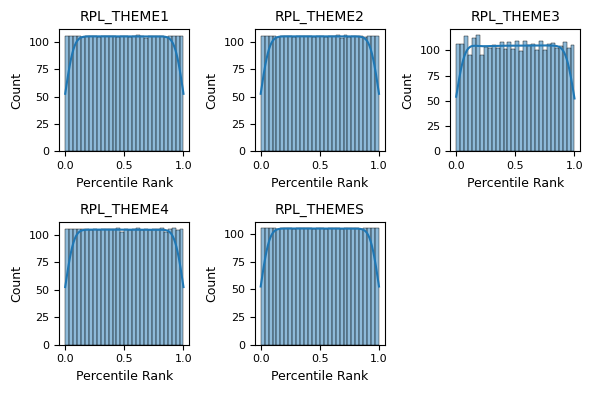

In [65]:
#| label: fig-svi-y-dist
#| fig-cap: "Distribution of county-level Social Vulnerability Index (SVI) percentile rankings across 3,144 U.S. counties. Each subplot shows the distribution of vulnerability scores for the four SVI themes and the overall SVI ranking (RPL_THEMES). Because these variables are defined as national percentile ranks, their distributions appear approximately uniform across counties, indicating that the targets are well-scaled within the [0,1] interval for regression-based multi-task modeling."
# Combine targets with overall SVI theme (RPL_THEMES)
plot_df = y.copy()
plot_df["RPL_THEMES"] = svi[overall_target]

themes = target_cols + overall_target

fig, axes = plt.subplots(2, 3, figsize=(6, 4))
axes = axes.flatten()

# Plot distributions
for i, theme in enumerate(themes):
    sns.histplot(
        plot_df[theme],
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(theme)
    axes[i].set_xlabel("Percentile Rank")
    axes[i].set_ylabel("Count")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

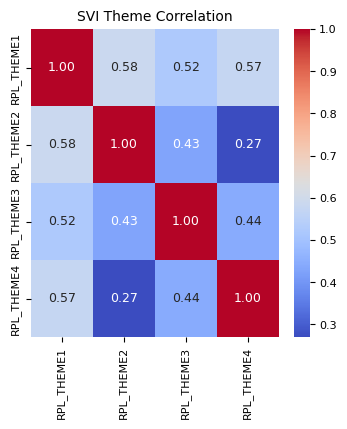

In [66]:
#| label: fig-svi-y-corr
#| fig-cap: "Correlation matrix of the four Social Vulnerability Index (SVI) theme percentile rankings across 3,144 U.S. counties. Moderate positive correlations are observed between several vulnerability dimensions, including socioeconomic status with household composition (r = 0.58) and housing/transportation (r = 0.57). Minority status and language vulnerability also shows moderate associations with other themes (r ≈ 0.43–0.52), while household composition exhibits weaker relationships with minority status (r = 0.43) and housing/transportation (r = 0.27). These relationships suggest that while themes capture related aspects of vulnerability, they remain distinct dimensions, motivating a multi-task learning approach for jointly predicting SVI themes."

corr = svi[target_cols].corr()

plt.figure(figsize=(4,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("SVI Theme Correlation")
plt.show()

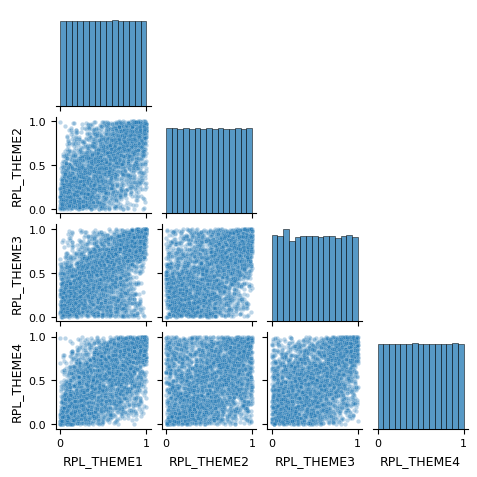

In [67]:
#| label: fig-svi-y-pairplot
#| fig-cap: "Pairwise relationships between the four Social Vulnerability Index (SVI) theme percentile rankings across 3,144 U.S. counties. Histograms along the diagonal show the approximately uniform distribution of percentile-based SVI theme scores, while scatter plots illustrate moderate positive associations between several vulnerability dimensions. These patterns indicate that counties experiencing one form of vulnerability often exhibit others, while still retaining distinct structural components."
sns.pairplot(
    svi[target_cols],
    corner=True,
    height=1.2,
    plot_kws={"alpha":0.3, "s":10}
)

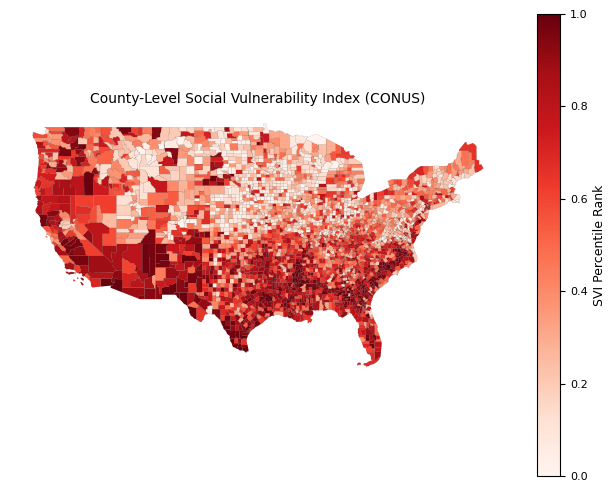

In [68]:
#| label: fig-svi-y-map
#| fig-cap: "County-level distribution of the Social Vulnerability Index (SVI) across the contiguous United States. Darker shades indicate higher vulnerability based on the CDC SVI percentile ranking (RPL_THEMES). The spatial clustering of vulnerability across neighboring counties suggests that geographic structure may provide useful information for predictive modeling, motivating the use of Graph Neural Networks."

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Remove Alaska, Hawaii, and territories
conus = geo_df[~geo_df["FIPS"].str.startswith(("02", "15", "60", "66", "69", "72", "78"))]

conus.plot(
    column="RPL_THEMES",
    cmap="Reds",
    linewidth=0.05,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "SVI Percentile Rank"},
    ax=ax
)

ax.set_title("County-Level Social Vulnerability Index (CONUS)")
ax.axis("off")

plt.show()

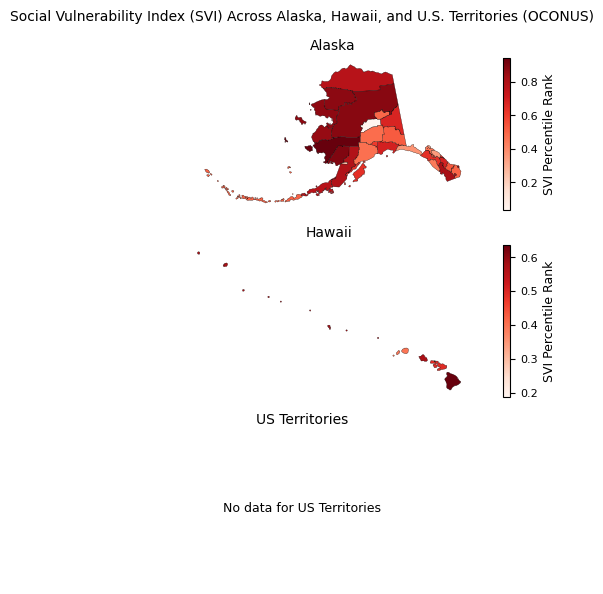

In [69]:
#| label: fig-svi-oconus
#| fig-cap: "County-level Social Vulnerability Index (SVI) percentile rankings for Alaska, Hawaii, and U.S. territories. These OCONUS regions are visualized separately from the CONUS to avoid geographic scaling distortions caused by their large spatial separation. Darker shades indicate higher social vulnerability based on the CDC SVI overall percentile ranking (RPL_THEMES). Missing SVI data for US territories."

# Define Alaska, Hawaii, and territories
ak = geo_df[geo_df["FIPS"].str.startswith("02")]
hi = geo_df[geo_df["FIPS"].str.startswith("15")]
territories = geo_df[geo_df["FIPS"].str.startswith(("60", "66", "69", "72", "78"))]

# Convert to specific CRS for reprojection
ak_proj = ak.to_crs("EPSG:3338")   
hi_proj = hi.to_crs("EPSG:3759")   
territories_proj = territories.to_crs("EPSG:3857")

fig, axes = plt.subplots(3, 1, figsize=(6, 6))

fig.suptitle(
    "Social Vulnerability Index (SVI) Across Alaska, Hawaii, and U.S. Territories (OCONUS)",
    fontsize=10
)

oconus_datasets = [
    (ak_proj, "Alaska"),
    (hi_proj, "Hawaii"),
    (territories_proj, "US Territories")
]

for ax, (data, title) in zip(axes, oconus_datasets):
    if data.empty:
        ax.text(0.5, 0.5, f"No data for {title}", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        continue

    data.plot(
        column="RPL_THEMES",
        cmap="Reds",
        linewidth=0.2,
        edgecolor="black",
        legend=True,
        legend_kwds={"label": "SVI Percentile Rank"},
        ax=ax
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Feature Matrix

In [72]:
X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns
)

### Feature Distribution & Correlation

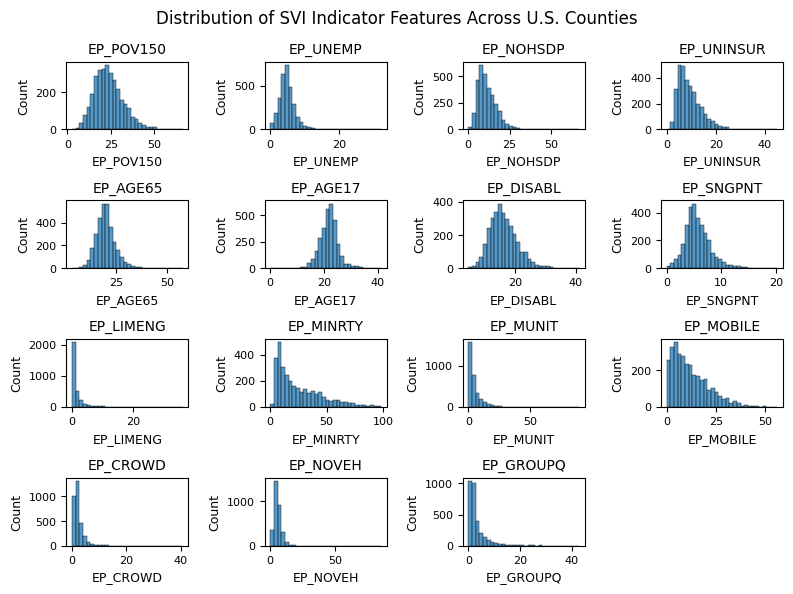

In [82]:
#| label: fig-svi-x-dist
#| fig-cap: "Distribution of county-level SVI indicator variables used as model input features. Each subplot shows the empirical distribution of a socioeconomic or demographic indicator across U.S. counties. These distributions provide insight into feature variability prior to model training."

features = X.columns[:16]

fig, axes = plt.subplots(4, 4, figsize=(8, 6))
axes = axes.flatten()

fig.suptitle(
    "Distribution of SVI Indicator Features Across U.S. Counties",
    fontsize=12
)

for i, col in enumerate(features):
    sns.histplot(X[col], bins=30, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

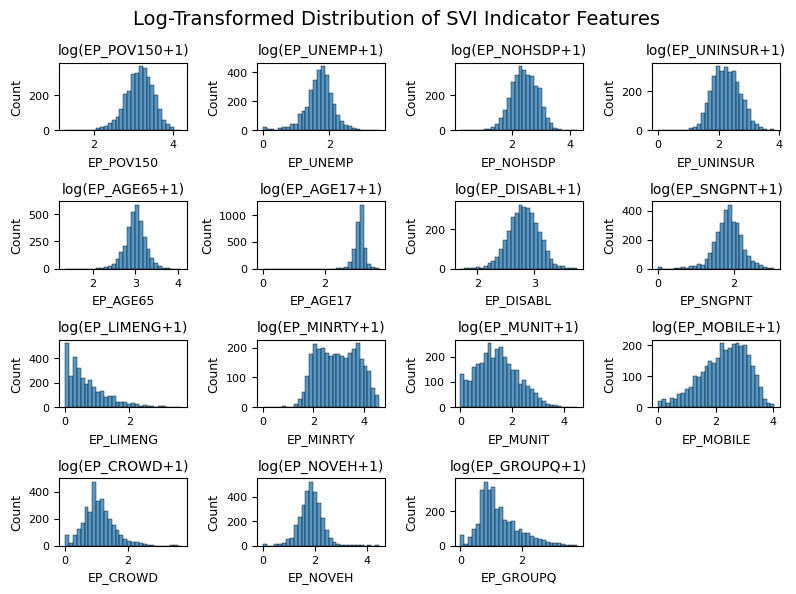

In [83]:
#| label: fig-svi-x-log-dist
#| fig-cap: "Log-transformed distributions of SVI indicator variables using log(x+1). Many census-derived indicators exhibit right-skewed distributions; the log transformation improves visualization of feature spread and highlights variation among lower-valued observations."

features = X.columns[:16]

fig, axes = plt.subplots(4, 4, figsize=(8, 6))
axes = axes.flatten()

fig.suptitle(
    "Log-Transformed Distribution of SVI Indicator Features",
    fontsize=14
)

for i, col in enumerate(features):
    sns.histplot(np.log1p(X[col]), bins=30, ax=axes[i])
    axes[i].set_title(f"log({col}+1)")

for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from libpysal.weights import Queen

# Build Queen contiguity weights
w = Queen.from_dataframe(df)

# Number of neighbors per county
degrees = pd.Series({node: len(neighbors) for node, neighbors in w.neighbors.items()})

display(degrees.describe())

#| label: fig-county-degree-dist
#| fig-cap: "Distribution of county neighbor counts in the spatial adjacency graph constructed using county boundary contiguity. The degree distribution summarizes how many neighboring counties each node is connected to, providing insight into the structural properties of the graph used for Graph Neural Network modeling."

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=20)

plt.title("County Neighbor Degree Distribution")
plt.xlabel("Number of Neighboring Counties")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Two-component PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "RPL_THEMES": df["RPL_THEMES"].values
})

display(pca_df.head())

In [ ]:
#| label: fig-pca-counties
#| fig-cap: "Two-dimensional PCA projection of county-level SVI input features. Counties are colored by overall social vulnerability (RPL_THEMES), allowing visual assessment of whether vulnerability aligns with structure in the feature space."

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["RPL_THEMES"],
    cmap="Reds",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, label="Overall SVI Percentile Rank")
plt.title("PCA Projection of Counties")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

In [ ]:
svi_geo.to_file("../data/processed/svi_county_geo.gpkg")